# LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from scipy.stats import gaussian_kde, iqr

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
file_path = "../1.DATASET/cmi_internet.csv"
df=pd.read_csv(file_path)
df.head(3)

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0


# Age

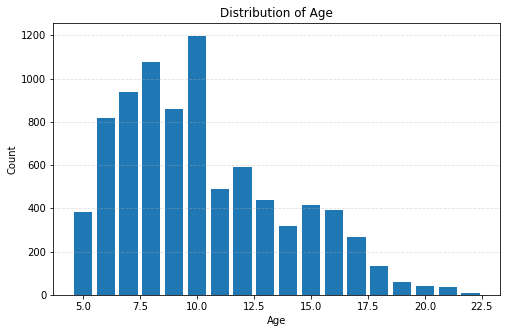

In [19]:
age_counts = df["Basic_Demos-Age"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(age_counts.index, age_counts.values)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Distribution of Age")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# CGAS Scores

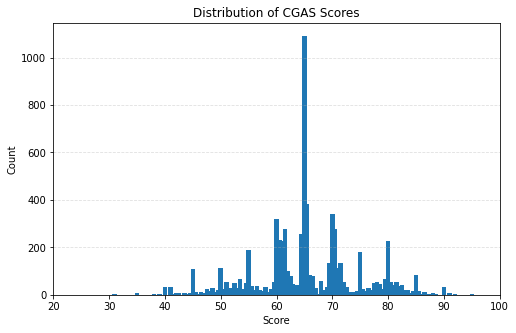

In [3]:
# see later: this high value distorts the distribution
score_counts = df["CGAS-CGAS_Score"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(score_counts.index, score_counts.values)

plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distribution of CGAS Scores")
plt.xlim(20, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

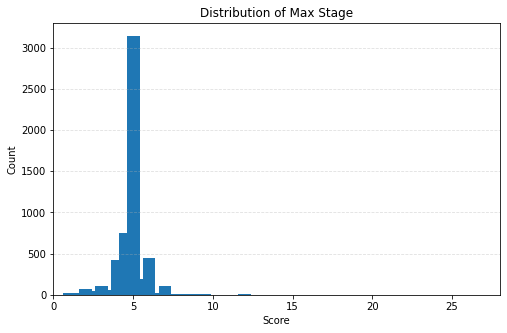

In [22]:
score_counts = df["Fitness_Endurance-Max_Stage"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(score_counts.index, score_counts.values)

plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distribution of Max Stage")
plt.xlim(0, 28)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

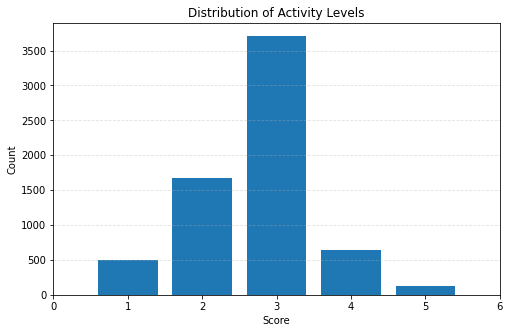

In [23]:
score_counts = df["BIA-BIA_Activity_Level_num"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(score_counts.index, score_counts.values)

plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distribution of Activity Levels")
plt.xlim(0, 6)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()


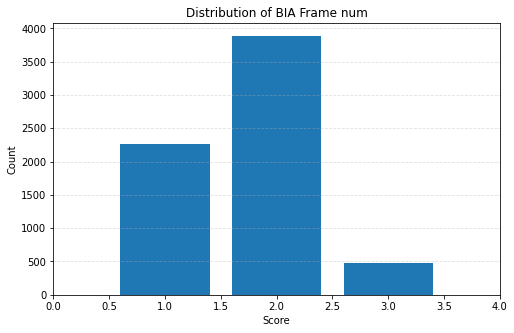

In [24]:
score_counts = df["BIA-BIA_Frame_num"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(score_counts.index, score_counts.values)

plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distribution of BIA Frame num")
plt.xlim(0, 4)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()


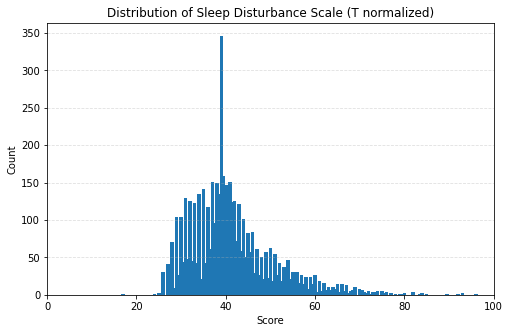

In [27]:
score_counts = df["SDS-SDS_Total_Raw"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(score_counts.index, score_counts.values)

plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distribution of Sleep Disturbance Scale (T normalized)")
plt.xlim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

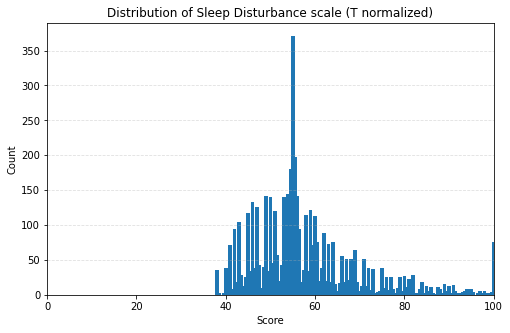

In [ ]:
score_counts = df["SDS-SDS_Total_T"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(score_counts.index, score_counts.values)

plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distribution of Sleep Disturbance Scale (T normalized)")
plt.xlim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

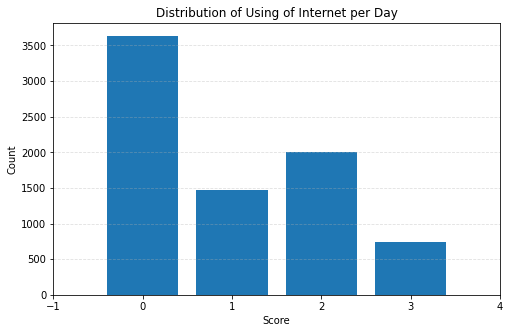

In [26]:
score_counts = df["PreInt_EduHx-computerinternet_hoursday"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(score_counts.index, score_counts.values)

plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distribution of Using of Internet per Day")
plt.xlim(-1, 4)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# BIAs

In [ ]:
x = df["BIA-BIA_Fat"]
y = df["BIA-BIA_DEE"]

plt.figure(figsize=(6,5))

plt.scatter(x, y, alpha=0.5)

plt.xlabel("Fat Mass")
plt.ylabel("DEE")
plt.title("Fat Mass vs DEE")
plt.xlim(-600, 400)
plt.ylim(0, 10000)

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

In [ ]:
cols = [
    "BIA-BIA_BMC",
    "BIA-BIA_BMI",
    "BIA-BIA_ECW",
    "BIA-BIA_FFM",
    "BIA-BIA_FFMI",
    "BIA-BIA_FMI",
    "BIA-BIA_Fat",
    "BIA-BIA_Frame_num",
    "BIA-BIA_ICW",
    "BIA-BIA_LDM",
    "BIA-BIA_LST",
    "BIA-BIA_SMM",
    "BIA-BIA_TBW"
]
"""cols = [
    "BIA-BIA_BMR",
    "BIA-BIA_DEE"
]"""

n = len(cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, ax = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
ax = ax.flatten()

for i, col in enumerate(cols):
    data = df[col].dropna().values
    kde = gaussian_kde(data, bw_method=0.3)

    x_vals = np.linspace(0, 1000, 200)

    ax[i].plot(x_vals, kde(x_vals), linewidth=2)
    ax[i].set_title(col)
    ax[i].set_xlim(0, 200)
    ax[i].grid(True, linestyle='--', alpha=0.4)

for j in range(len(cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()


In [ ]:
cols = [
    "BIA-BIA_BMC",
    "BIA-BIA_BMI",
    "BIA-BIA_BMR",
    "BIA-BIA_DEE",
    "BIA-BIA_ECW",
    "BIA-BIA_FFM",
    "BIA-BIA_FFMI",
    "BIA-BIA_FMI",
    "BIA-BIA_Fat",
    "BIA-BIA_Frame_num",
    "BIA-BIA_ICW",
    "BIA-BIA_LDM",
    "BIA-BIA_LST",
    "BIA-BIA_SMM",
    "BIA-BIA_TBW"
]

n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, ax = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
ax = ax.flatten()

for i, col in enumerate(cols):
    data = df[col].dropna().values

    # Freedman-Diaconis rule: bin width = 2 * IQR * n^(-1/3)
    bin_width = 2 * iqr(data) * len(data) ** (-1/3)
    if bin_width == 0:
        bin_width = 1  # fallback se IQR = 0
    n_bins = int(np.ceil((data.max() - data.min()) / bin_width))
    n_bins = max(n_bins, 10)  # almeno 10 bin

    ax[i].hist(data, bins=n_bins, edgecolor="black", color="steelblue", alpha=0.8)
    ax[i].set_title(col, fontsize=10)
    ax[i].set_xlim(0, 400)
    ax[i].set_xlabel("Valore")
    ax[i].set_ylabel("Frequenza")
    ax[i].grid(True, linestyle="--", alpha=0.4)

for j in range(len(cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

# Physical attributes

## general overview

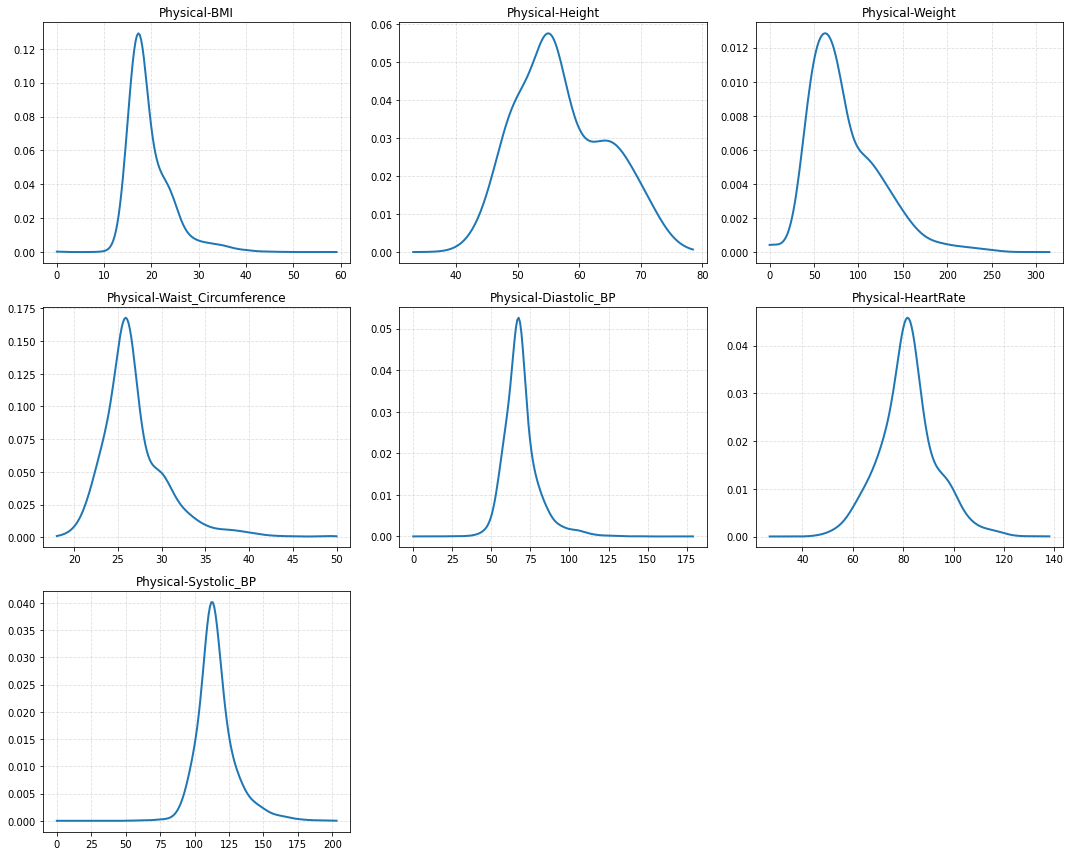

In [21]:
cols = [
    'Physical-BMI',
    'Physical-Height',
    'Physical-Weight',
    'Physical-Waist_Circumference',
    'Physical-Diastolic_BP',
    'Physical-HeartRate',
    'Physical-Systolic_BP'
]

fig, ax = plt.subplots(3, 3, figsize=(15, 12))
ax = ax.flatten()

for i, col in enumerate(cols):
    data = df[col].dropna().values
    kde = gaussian_kde(data, bw_method=0.3)

    x_vals = np.linspace(data.min(), data.max(), 200)

    ax[i].plot(x_vals, kde(x_vals), linewidth=2)
    ax[i].set_title(col)
    ax[i].grid(True, linestyle='--', alpha=0.4)

# rimuove i subplot vuoti (perché 9 spazi ma 7 variabili)
for j in range(len(cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

#from this I would say:
#physical height: we drop
# weight: has a similar shape to waist circumference, so drop weight and keep circumference
#diastolic and systolic have the same shape, so we can do something 
#heartrate: keep

## Weight vs Height

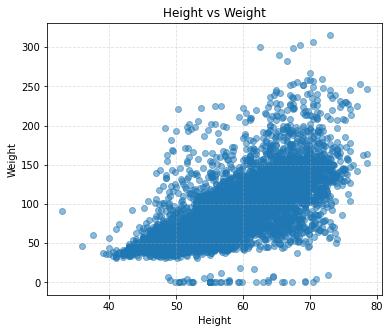

In [22]:
x = df["Physical-Height"]
y = df["Physical-Weight"]

plt.figure(figsize=(6,5))

plt.scatter(x, y, alpha=0.5)

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Height vs Weight")

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

## Systolic and diastolic

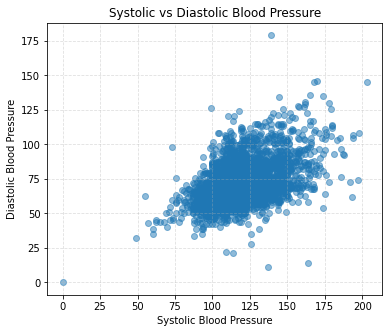

In [23]:

x = df["Physical-Systolic_BP"]
y = df["Physical-Diastolic_BP"]

plt.figure(figsize=(6,5))

plt.scatter(x, y, alpha=0.5)

plt.xlabel("Systolic Blood Pressure")
plt.ylabel("Diastolic Blood Pressure")
plt.title("Systolic vs Diastolic Blood Pressure")

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

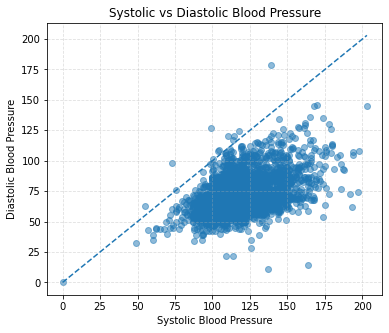

In [24]:
plt.figure(figsize=(6,5))
plt.scatter(x, y, alpha=0.5)

# linea y = x
vals = np.linspace(min(x.min(), y.min()), max(x.max(), y.max()))
plt.plot(vals, vals, linestyle="--")

plt.xlabel("Systolic Blood Pressure")
plt.ylabel("Diastolic Blood Pressure")
plt.title("Systolic vs Diastolic Blood Pressure")

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## "Heart" variables vs Weight

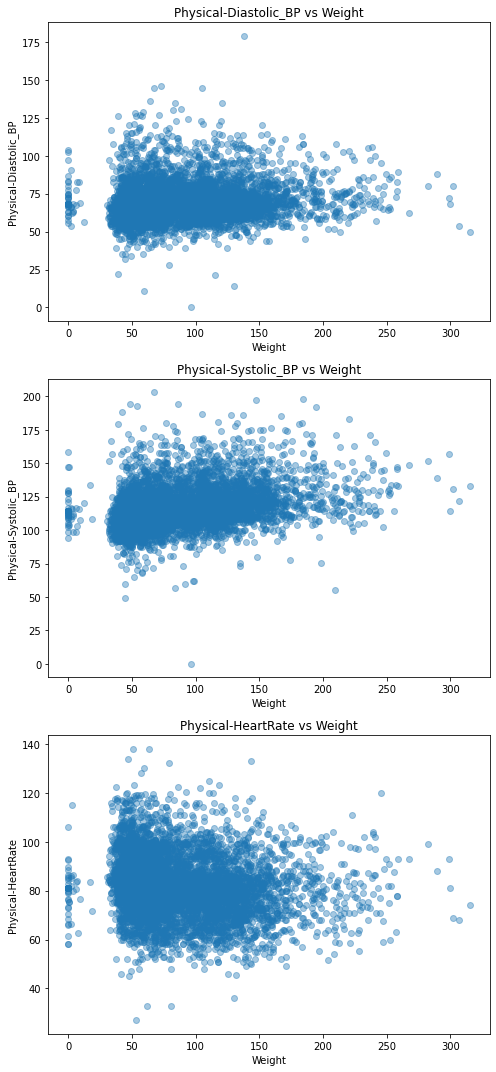

In [ ]:
# I would have expected a more positive correlation

cols = [
    "Physical-Diastolic_BP",
    "Physical-Systolic_BP",
    "Physical-HeartRate"
]

fig, ax = plt.subplots(3, 1, figsize=(7,15))

for i, col in enumerate(cols):

    ax[i].scatter(
        df["Physical-Weight"],
        df[col],
        alpha=0.4
    )

    ax[i].set_xlabel("Weight")
    ax[i].set_ylabel(col)
    ax[i].set_title(f"{col} vs Weight")

plt.tight_layout()
plt.show()

In [64]:
variance = df["Physical-HeartRate"].var()
print(variance)

129.5165205669178


## "Heart" variables vs Age

/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_812/3270919650.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_812/3270919650.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend()
/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_812/3270919650.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_812/3270919650.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label st

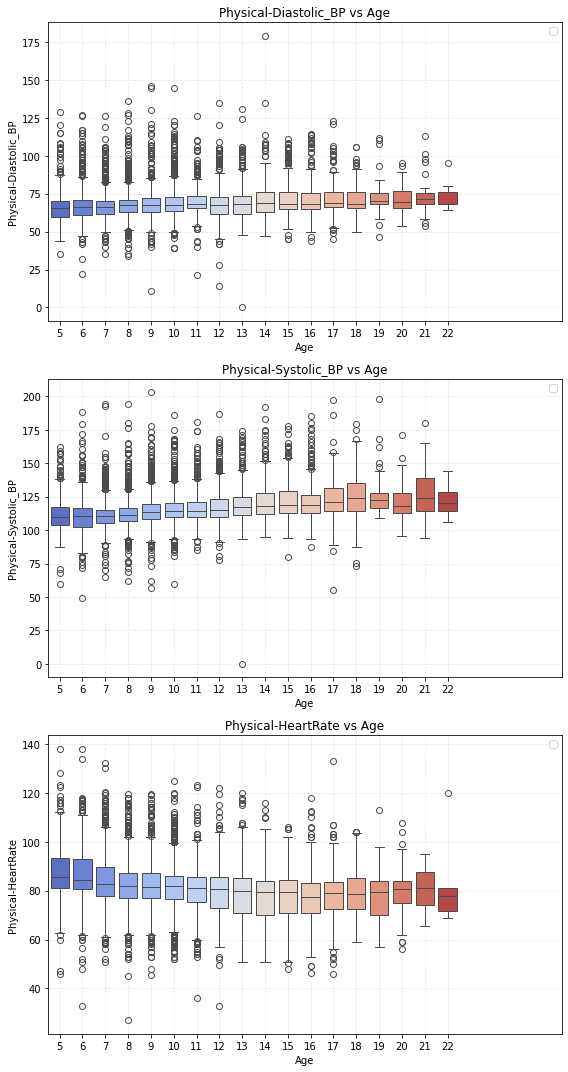

In [ ]:
cols = [
    "Physical-Diastolic_BP",
    "Physical-Systolic_BP",
    "Physical-HeartRate"
]

fig, ax = plt.subplots(3, 1, figsize=(8,15))

for i, col in enumerate(cols):
    sns.boxplot(
        x="Basic_Demos-Age",
        y=col,
        data=df,
        ax=ax[i],
        palette="coolwarm"
    )

    # aggiungi linea della media per ogni età
    means = df.groupby("Basic_Demos-Age")[col].mean()
    #ax[i].plot(range(len(means)), means.values, color='black', linestyle='--', marker='o', label='Mean')
    ax[i].set_xlabel("Age")
    ax[i].set_ylabel(col)
    ax[i].set_title(f"{col} vs Age")
    ax[i].legend()
    ax[i].set_xlim(-0.5, 22)
    ax[i].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Height, Weight, BMI vs Age

/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_812/382625198.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_812/382625198.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_812/382625198.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


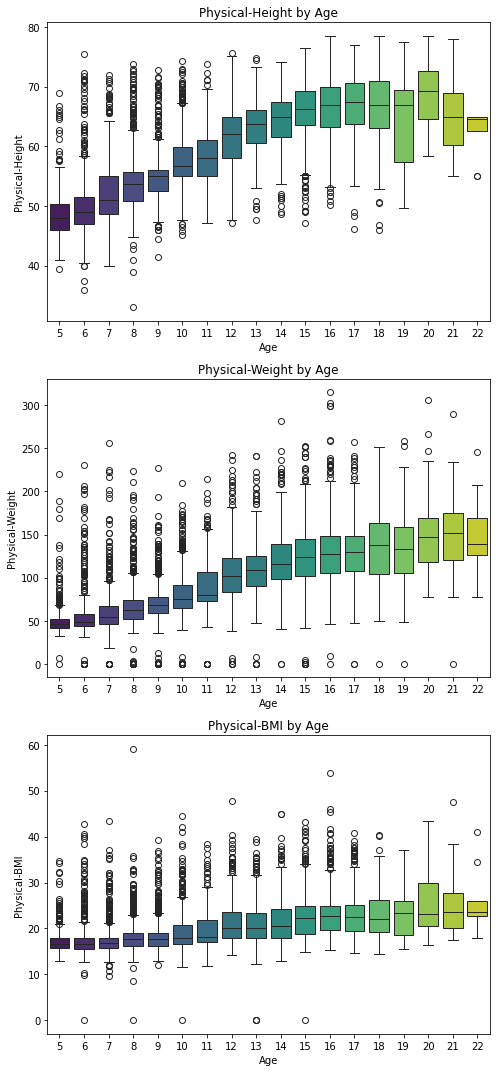

In [42]:
cols = [
    "Physical-Height",
    "Physical-Weight",
    "Physical-BMI"
]

fig, ax = plt.subplots(3, 1, figsize=(7,15))

for i, col in enumerate(cols):

    sns.boxplot(
        x=df["Basic_Demos-Age"],
        y=df[col],
        ax=ax[i],
        palette="viridis"
    )

    ax[i].set_xlabel("Age")
    ax[i].set_ylabel(col)
    ax[i].set_title(f"{col} by Age")

plt.tight_layout()
plt.show()

In [65]:
variance = df["Physical-BMI"].var()
print(variance)

21.93915268121644


## Weight, Height, Age vs Waist Circumference

/var/folders/z_/h8pm6bx50mngk0pbk5p07btc0000gn/T/ipykernel_812/3234469899.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


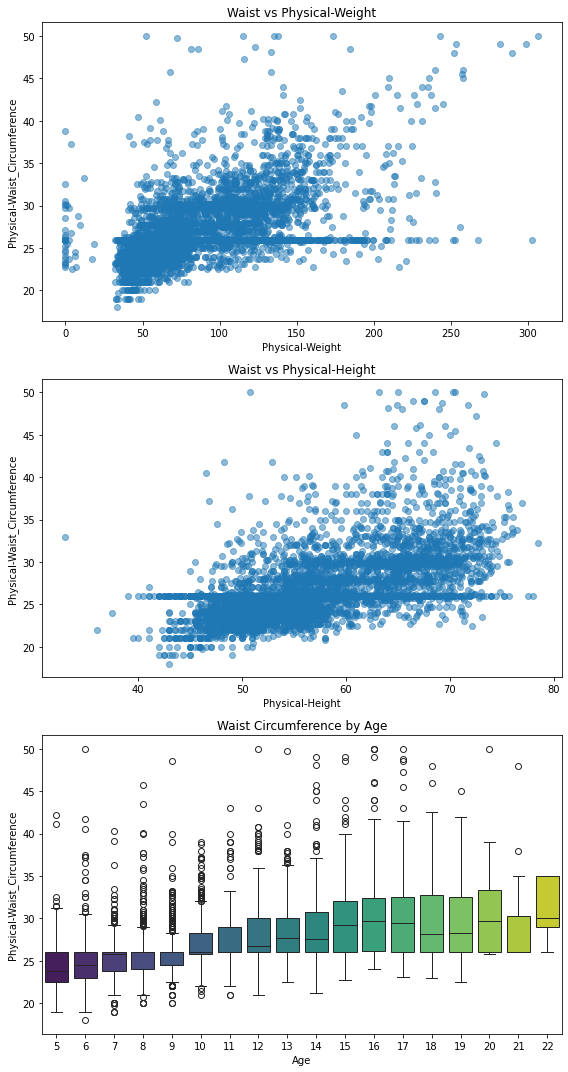

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["Physical-Weight", "Physical-Height", "Basic_Demos-Age"]

fig, ax = plt.subplots(3, 1, figsize=(8,15))

# Scatter plot per Weight e Height vs Waist
for i, col in enumerate(cols[:-1]):  # esclude Age
    ax[i].scatter(
        df[col],
        df["Physical-Waist_Circumference"],
        alpha=0.5
    )
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Physical-Waist_Circumference")
    ax[i].set_title(f"Waist vs {col}")

# Boxplot per Age vs Waist
sns.boxplot(
    x="Basic_Demos-Age",
    y="Physical-Waist_Circumference",
    data=df,
    ax=ax[2],
    palette="viridis"
)
ax[2].set_xlabel("Age")
ax[2].set_ylabel("Physical-Waist_Circumference")
ax[2].set_title("Waist Circumference by Age")

plt.tight_layout()
plt.show()

In [29]:
df["Physical-Waist_Circumference"].value_counts()

Physical-Waist_Circumference
26.00    1633
25.75     182
23.75     173
27.75     159
29.75     128
         ... 
18.00       1
38.10       1
42.25       1
39.50       1
20.75       1
Name: count, Length: 129, dtype: int64

# Max Stage vs time

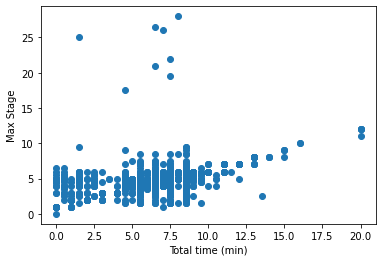

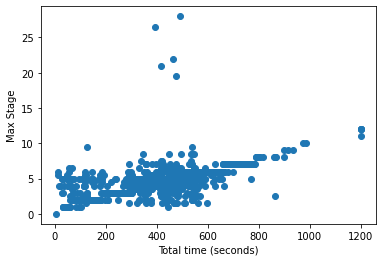

In [30]:
# this shows that the stage does not depend only on the time.
# probably we should keep the max stage bc it's more informative, since that for the same time we can have different stages

df["Fitness_Endurance_Time_Total"] = (
    df["Fitness_Endurance-Time_Mins"]*60 +
    df["Fitness_Endurance-Time_Sec"]
)

#some values disappear bc of missing values.

plt.scatter(df["Fitness_Endurance-Time_Mins"],
            df["Fitness_Endurance-Max_Stage"])

plt.xlabel("Total time (min)")
plt.ylabel("Max Stage")
plt.show()

plt.scatter(df["Fitness_Endurance_Time_Total"],
            df["Fitness_Endurance-Max_Stage"])

plt.xlabel("Total time (seconds)")
plt.ylabel("Max Stage")
plt.show()

# MAx stage vs heart rate

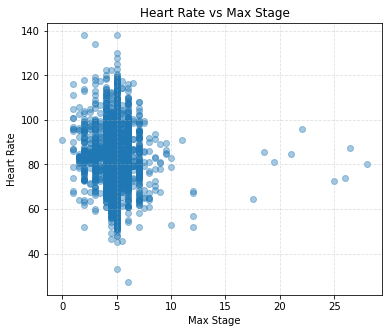

In [37]:

plt.figure(figsize=(6,5))

plt.scatter(
    df["Fitness_Endurance-Max_Stage"],
    df["Physical-HeartRate"],
    alpha=0.4
)

plt.xlabel("Max Stage")
plt.ylabel("Heart Rate")

plt.title("Heart Rate vs Max Stage")

plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

# FGC vs Zone

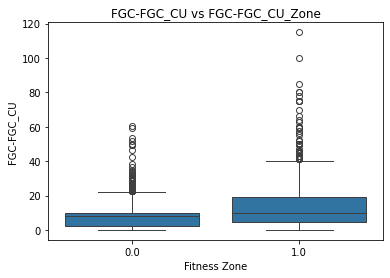

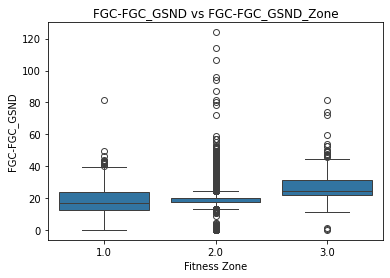

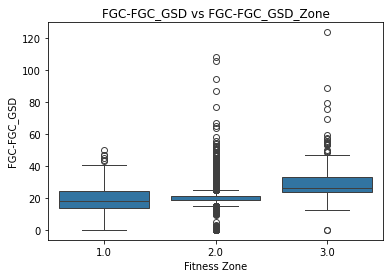

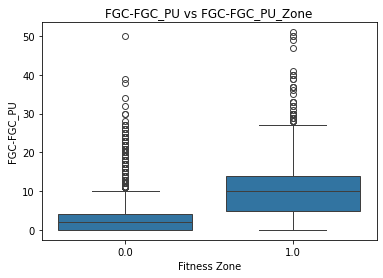

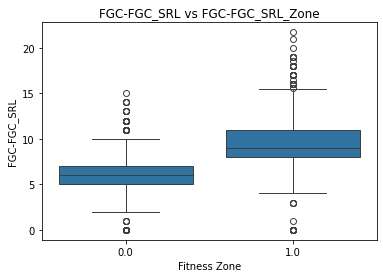

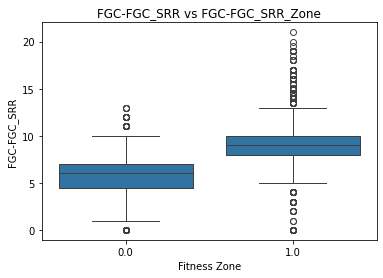

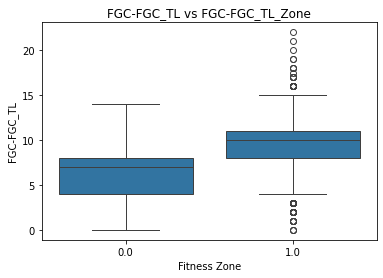

In [32]:
# also here the score got in FGCs is not the only factor that determines the "fitness zone", since the margins of the zone overlap
# this time FGCs are more informative 
tests = [
    ("FGC-FGC_CU","FGC-FGC_CU_Zone"),
    ("FGC-FGC_GSND","FGC-FGC_GSND_Zone"),
    ("FGC-FGC_GSD","FGC-FGC_GSD_Zone"),
    ("FGC-FGC_PU","FGC-FGC_PU_Zone"),
    ("FGC-FGC_SRL","FGC-FGC_SRL_Zone"),
    ("FGC-FGC_SRR","FGC-FGC_SRR_Zone"),
    ("FGC-FGC_TL","FGC-FGC_TL_Zone")
]

for score, zone in tests:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df[zone], y=df[score])
    
    plt.xlabel("Fitness Zone")
    plt.ylabel(score)
    plt.title(f"{score} vs {zone}")
    
    plt.show()

# BMI vs Weight

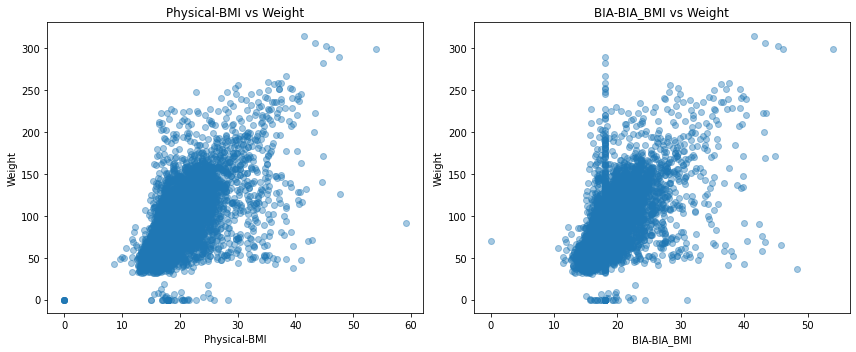

In [33]:
cols = [
    "Physical-BMI",
    "BIA-BIA_BMI"
]

fig, ax = plt.subplots(1,2, figsize=(12,5))

for i, col in enumerate(cols):

    ax[i].scatter(
        df[col],
        df["Physical-Weight"],
        alpha=0.4
    )

    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Weight")
    ax[i].set_title(f"{col} vs Weight")

plt.tight_layout()
plt.show()

In [51]:
import pandas as pd

bins = [5, 8, 11, 14, 18, 21, 23]  # definisce i bordi: [0‑5], [6‑12], [13‑17], [18‑22]
labels = ["5-7", "8-10", "11-13", "14-17", "18-20", "21-23"]

df["AgeGroup"] = pd.cut(
    df["Basic_Demos-Age"],
    bins=bins,
    labels=labels,
    right=False  
)

# All attributes grouped by sex and age

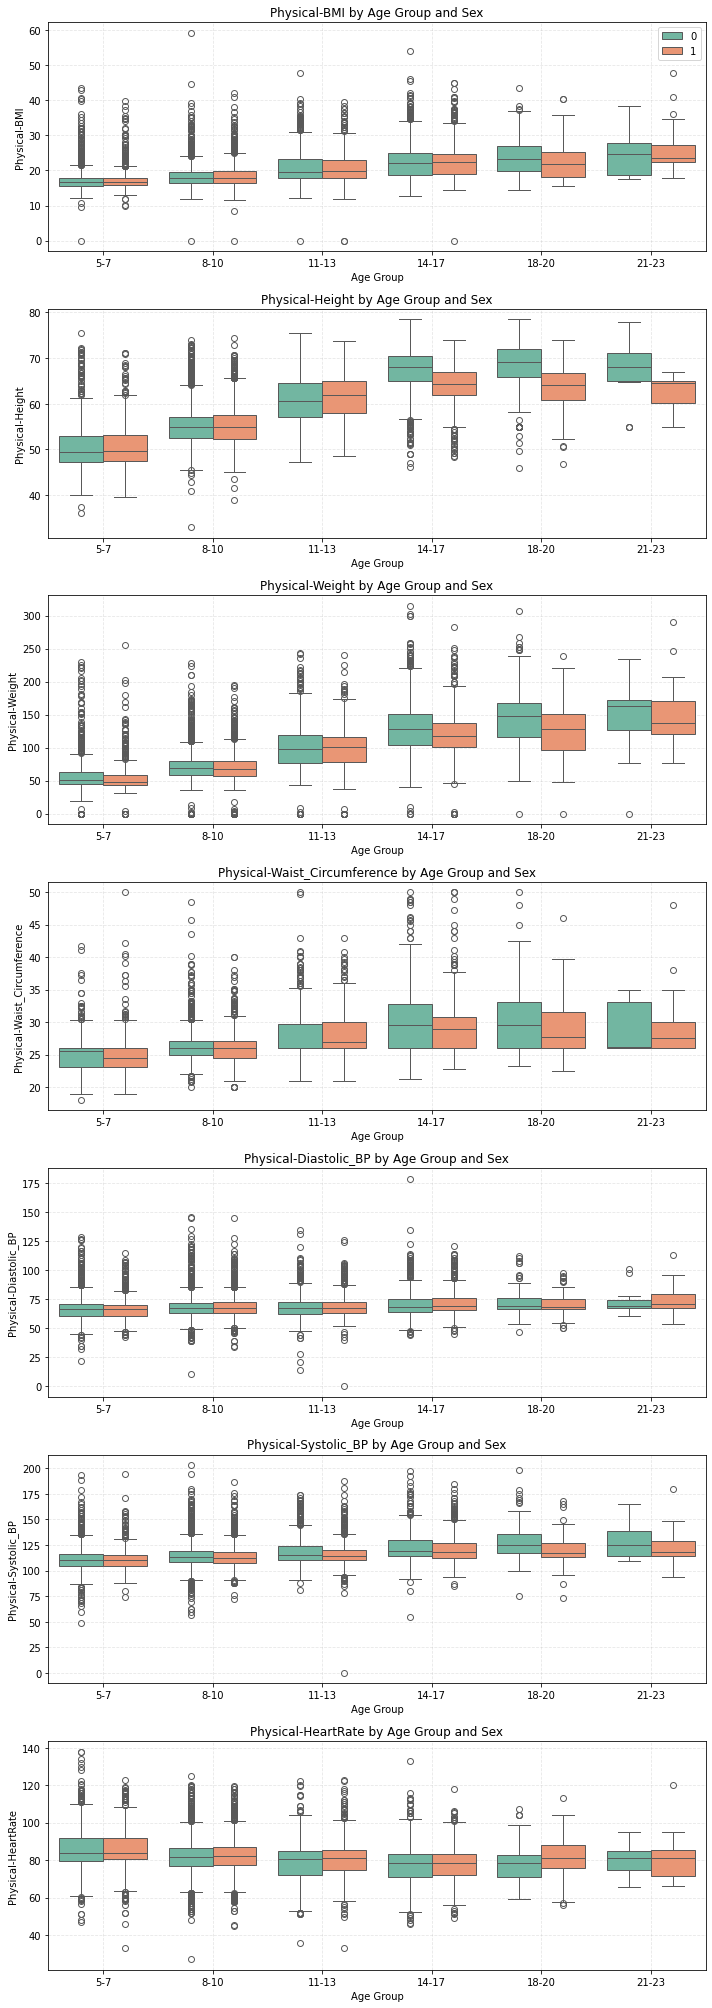

In [ ]:
# I think it's 0 male 1 female
cols = [
    'Physical-BMI',
    'Physical-Height',
    'Physical-Weight',
    'Physical-Waist_Circumference',
    'Physical-Diastolic_BP',
    'Physical-Systolic_BP',
    'Physical-HeartRate'
]

fig, axes = plt.subplots(len(cols), 1, figsize=(10, len(cols)*4))

for i, col in enumerate(cols):
    ax = axes[i]
    sns.boxplot(
        x="AgeGroup",
        y=col,
        hue="Basic_Demos-Sex",
        data=df,
        ax=ax,
        palette="Set2"
    )

    ax.set_title(f"{col} by Age Group and Sex")
    ax.set_xlabel("Age Group")
    ax.set_ylabel(col)
    ax.grid(True, linestyle="--", alpha=0.3)
    if i != 0:
        ax.get_legend().remove()
    else:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

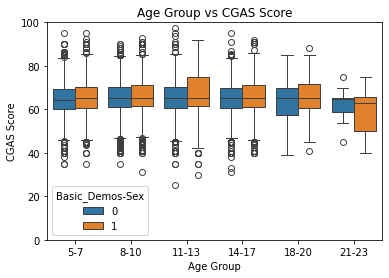

In [59]:
plt.figure(figsize=(6,4))
    
sns.boxplot(x=df["AgeGroup"], y=df['CGAS-CGAS_Score'], hue=df["Basic_Demos-Sex"])
    
plt.xlabel("Age Group")
plt.ylabel("CGAS Score")
plt.title("Age Group vs CGAS Score")
plt.ylim(0,100)
    
plt.show()


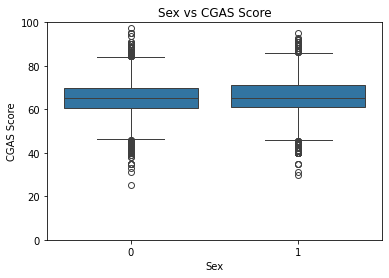

In [62]:
plt.figure(figsize=(6,4))
    
sns.boxplot(x=df["Basic_Demos-Sex"], y=df['CGAS-CGAS_Score'])
    
plt.xlabel("Sex")
plt.ylabel("CGAS Score")
plt.title("Sex vs CGAS Score")
plt.ylim(0,100)
    
plt.show()

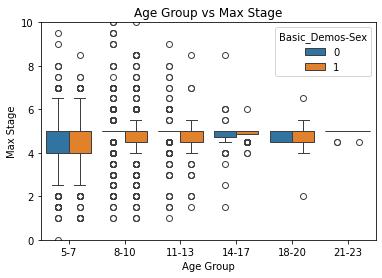

In [61]:
plt.figure(figsize=(6,4))
    
sns.boxplot(x=df["AgeGroup"], y=df['Fitness_Endurance-Max_Stage'], hue=df["Basic_Demos-Sex"])
    
plt.xlabel("Age Group")
plt.ylabel("Max Stage")
plt.title("Age Group vs Max Stage")
plt.ylim(0,10)
    
plt.show()